In [1]:
# Import core libraries for data handling
import pandas as pd
import numpy as np

# Import ML utilities
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Pipeline to combine preprocessing + model
from sklearn.pipeline import Pipeline

# Machine learning model
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib

In [ ]:
# Load Datasets

In [6]:
# Load telecom churn dataset
df = pd.read_csv("../churn.csv")

# Remove ID column because it has no predictive value
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric because dataset stores it as string
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values with 0
df.fillna(0, inplace=True)

# Preview dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Feature / Target Split

In [7]:
# Separate features and target variable
X = df.drop("Churn", axis=1)

# Target variable (customer churn yes/no)
y = df["Churn"]

In [ ]:
# Identify Feature Types

In [8]:
# Identify categorical columns
categorical_features = X.select_dtypes(include="object").columns

# Identify numerical columns
numerical_features = X.select_dtypes(exclude="object").columns

In [ ]:
# Build Preprocessing pipeline

In [9]:
# ColumnTransformer allows different preprocessing for different column types

preprocessor = ColumnTransformer(
    transformers=[
        # Standardize numeric variables
        ("num", StandardScaler(), numerical_features),

        # Convert categorical variables to numeric using OneHotEncoding
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
# Build ML pipeline

In [10]:
# Combine preprocessing + model in one pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        # RandomForest is robust for tabular datasets
        ("model", RandomForestClassifier(random_state=42))
    ]
)

In [ ]:
# Train Test Split

In [11]:
# Split dataset into training and testing sets
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Hyperparameter Tuning

In [12]:
# Define hyperparameter search space

param_grid = {
    "model__n_estimators":[100,200,300],
    "model__max_depth":[5,10,None],
    "model__min_samples_split":[2,5]
}

# GridSearchCV finds best parameters using cross-validation

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Train models
grid.fit(X_train, y_train)

# Best model after tuning
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [ ]:
# Model Evaluation / Evaluate Model

In [13]:
# Make predictions on test data
preds = best_model.predict(X_test)

# Probability predictions
probs = best_model.predict_proba(X_test)[:,1]

# Accuracy
print("Accuracy:", accuracy_score(y_test, preds))

# ROC AUC score
print("ROC AUC:", roc_auc_score(y_test, probs))

# Detailed metrics
print(classification_report(y_test, preds))

Accuracy: 0.801277501774308
ROC AUC: 0.8626522922769572
              precision    recall  f1-score   support

          No       0.82      0.93      0.87      1036
         Yes       0.70      0.44      0.54       373

    accuracy                           0.80      1409
   macro avg       0.76      0.68      0.71      1409
weighted avg       0.79      0.80      0.78      1409



In [ ]:
# Feature Importance (Business Insight)

In [14]:
# Extract feature names after encoding

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Extract importance from RandomForest
importances = best_model.named_steps["model"].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "feature":feature_names,
    "importance":importances
}).sort_values("importance", ascending=False)

# Top drivers of churn
importance_df.head(10)

,feature,importance
36,cat__Contract_Month-to-month,0.162006
1,num__tenure,0.161082
18,cat__OnlineSecurity_No,0.095371
27,cat__TechSupport_No,0.075425
16,cat__InternetService_Fiber optic,0.070898
3,num__TotalCharges,0.070497
38,cat__Contract_Two year,0.056069
43,cat__PaymentMethod_Electronic check,0.048650
2,num__MonthlyCharges,0.031421
15,cat__InternetService_DSL,0.026520


In [ ]:
# Visualise feature importance

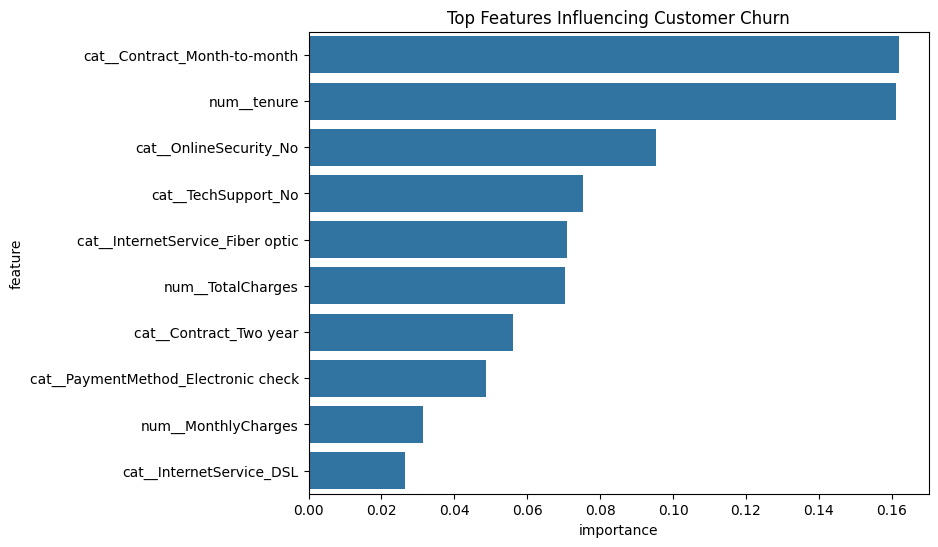

In [15]:
# Plot top 10 features influencing churn

plt.figure(figsize=(8,6))

sns.barplot(
    x="importance",
    y="feature",
    data=importance_df.head(10)
)

plt.title("Top Features Influencing Customer Churn")

plt.show()

In [16]:
# Save trained pipeline including preprocessing

joblib.dump(best_model, "../model.pkl")

print("Model saved successfully")

Model saved successfully
